## Imports Section:

In [94]:
import numpy as np
import pandas as pd
import random
import scipy
from scipy import stats
import datetime as dt
import dask.dataframe as dd

In [95]:
import librosa
import warnings

In [96]:
import glob
import matplotlib.pyplot as plt
from matplotlib import colors
import soundfile as sf
import matplotlib.patches as patches
from pathlib import Path

In [97]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm

In [98]:
import sys

# append the path of the
# parent directory
sys.path.append('..')
sys.path.append('../src/')
sys.path.append('../src/models/bat_call_detector/batdetect2/')

import src.batdt2_pipeline as batdetect2_pipeline
import src.file_dealer as file_dealer

## Function Definitions (most important functions are in `src/`)
### Below are the functions used for plotting and visualization

In [99]:
def convert_bd2df_ravenpro(df: pd.DataFrame):
    """
    Converts a dataframe to the format used by RavenPro
    """

    ravenpro_df = df.copy()

    ravenpro_df.rename(columns={
        "start_time": "Begin Time (s)",
        "end_time": "End Time (s)",
        "low_freq": "Low Freq (Hz)",
        "high_freq": "High Freq (Hz)",
        "event": "Annotation",
        "freq_group":"Manually-Verified Phonic Group",
        'snr_nist_quick_dB':'SNR NIST Quick (dB)',
        'delta_time_s':'Delta Time (s)'
    }, inplace=True)

    ravenpro_df["Selection"] = np.arange(0, df.shape[0]).astype('int') + 1
    ravenpro_df["View"] = "Waveform 1"
    ravenpro_df["Channel"] = "1"

    return ravenpro_df

In [100]:
FREQ_COLORS = {'LF':'cyan', 'HF':'orange'}

In [101]:
file_sites = {'20220730_053000':'Carp',
 '20220826_070000':'Central',
 '20220727_083000':'Foliage',
 '20220829_090000':'Foliage'}
bd2_dets_save_dir = Path(f'20250115__group_threshold_sweep_results')
raventxt_human_files_dir = f'{Path.home()}/Documents/Research/mila_files/mila-human-wav-txt'
extension = ".txt"
sep = "\t"

SITE_NAMES = {'Carp':'Carp Pond', 'Foliage':'Foliage', 'Central':'Central Pond'}

file_keys = list(file_sites.keys())
file_keys

['20220730_053000', '20220826_070000', '20220727_083000', '20220829_090000']

In [102]:
def return_confusion_matrix_from_comparing_two_detectors(human_df, machine_df):
    dist_matrix = np.zeros((len(machine_df), len(human_df)))
    association_matrix = np.zeros((len(machine_df), len(human_df)), dtype='bool')
    for index in range(len(machine_df)):
        batdetect2_row = machine_df.iloc[index]
        dist_to_all_calls = ((human_df['peak_frequency_time'] - batdetect2_row['peak_frequency_time_SPECTROGRAM']).values)
        dist_matrix[index,:] = dist_to_all_calls
    
        dist_to_all_calls[np.abs(dist_to_all_calls)>=0.001] = 1
        dist_to_all_calls[np.abs(dist_to_all_calls)<0.001] = 0
        association_matrix[index,:] = ~dist_to_all_calls.astype('bool')

    human_bd2_true_positives = human_df.loc[np.logical_or.reduce(association_matrix, axis=0)]
    bd2_false_negatives = human_df.loc[~(np.logical_or.reduce(association_matrix, axis=0))]
    bd2_true_positives = machine_df.loc[np.logical_or.reduce(association_matrix, axis=1)]
    bd2_false_positives = machine_df.loc[~(np.logical_or.reduce(association_matrix, axis=1))]

    return {'true_positives':len(bd2_true_positives), 
            'false_positives':len(bd2_false_positives), 
            'false_negatives':len(bd2_false_negatives), 
            'true_negatives':0}

## Following the confusion matrix structure shown below

![image](example_confusion_matrix.png)

In [103]:
def get_precision_and_recall_from_metrics(true_positives, false_positives, false_negatives):
    denom_precision = (true_positives + false_positives)
    denom_recall = (true_positives + false_negatives)
    if (denom_precision>0):
        precision = true_positives / denom_precision
    else:
        precision = np.NaN
    if (denom_recall>0):
        recall = true_positives / denom_recall
    else:
        recall = np.NaN
    
    return precision, recall

In [104]:
def gather_evaluation_results_between_bd2_and_human(bd2_human_df, batdetect2_df_thresh):
    file_batdetect2_cf = return_confusion_matrix_from_comparing_two_detectors(bd2_human_df, batdetect2_df_thresh)
    precision, recall = get_precision_and_recall_from_metrics(file_batdetect2_cf['true_positives'], 
                                                              file_batdetect2_cf['false_positives'], 
                                                              file_batdetect2_cf['false_negatives'])

    return file_batdetect2_cf, precision, recall

In [105]:
def apply_SNR_threshold_on_both_sets(bd2_human_df, batdetect2_df, SNR_thresh):
    bd2_human_df_SNR = bd2_human_df[bd2_human_df['adityas_method_snr_dB']>=SNR_thresh].copy()
    batdetect2_df_SNR = batdetect2_df[batdetect2_df['SNR']>=SNR_thresh].copy()

    return bd2_human_df_SNR, batdetect2_df_SNR

In [106]:
def make_new_row_in_eval_df(file_batdetect2_cf, precision, recall):
    row = pd.DataFrame([file_batdetect2_cf])
    row['precision'] = precision
    row['recall'] = recall

    return row

In [107]:
def generate_evaluation_df(bd2_human_df, batdetect2_df):
    batdetect2_eval = pd.DataFrame()

    increment = 2.0
    snr_thresholds = np.arange(0, 22+increment, increment)
    for snr_thresh in snr_thresholds:
        bd2_human_df_SNR, batdetect2_df_SNR = apply_SNR_threshold_on_both_sets(bd2_human_df, batdetect2_df, snr_thresh)

        increment = 0.01
        detection_thresholds = np.arange(0.05, 0.6+increment, increment)
        for det_thresh in detection_thresholds:
            det_thresh = round(det_thresh, 2)
            print(snr_thresh, det_thresh)
            batdetect2_df_SNR_detthresh = batdetect2_df_SNR[batdetect2_df_SNR['det_prob']>=det_thresh].copy()
            file_batdetect2_cf, precision, recall = gather_evaluation_results_between_bd2_and_human(bd2_human_df_SNR, 
                                                                                                    batdetect2_df_SNR_detthresh)
            row = make_new_row_in_eval_df(file_batdetect2_cf, precision, recall)
            row.insert(0, 'num_human_annotations', [len(bd2_human_df_SNR)])
            row.insert(0, 'num_bd2_detections', [len(batdetect2_df_SNR_detthresh)])
            row.insert(0, 'detection_threshold', [det_thresh])
            row.insert(0, 'SNR_threshold', [snr_thresh])
            batdetect2_eval = pd.concat([batdetect2_eval, row])
            assert(len(batdetect2_df_SNR_detthresh['freq_group'].unique())<=2)

    batdetect2_eval.reset_index(drop=True, inplace=True)
    return batdetect2_eval

In [174]:
def return_true_positives_using_human_df(human_df, machine_df, debug=True):
    dist_matrix = np.zeros((len(machine_df), len(human_df)))
    association_matrix = np.zeros((len(machine_df), len(human_df)), dtype='bool')
    collect_human = pd.DataFrame()
    collect_bd2 = pd.DataFrame()
    for index in range(len(machine_df)):
        batdetect2_row = machine_df.iloc[index]
        dist_to_all_calls = ((human_df['peak_frequency_time'] - batdetect2_row['peak_frequency_time_SPECTROGRAM']).values)
        dist_matrix[index,:] = dist_to_all_calls
    
        dist_to_all_calls[np.abs(dist_to_all_calls)>=0.001] = 1
        dist_to_all_calls[np.abs(dist_to_all_calls)<0.001] = 0
        if np.abs(dist_to_all_calls-1).sum() > 1:
            collect_human = pd.concat([collect_human, human_df[dist_to_all_calls<0.5]])
            collect_bd2 = pd.concat([collect_bd2, pd.DataFrame(batdetect2_row).T])

        association_matrix[index,:] = ~dist_to_all_calls.astype('bool')

    human_bd2_true_positives = human_df.loc[np.logical_or.reduce(association_matrix, axis=0)]
    machine_false_negatives = human_df.loc[~(np.logical_or.reduce(association_matrix, axis=0))]
    machine_true_positives = machine_df.loc[np.logical_or.reduce(association_matrix, axis=1)]
    machine_false_positives = machine_df.loc[~(np.logical_or.reduce(association_matrix, axis=1))]

    return machine_true_positives, len(machine_true_positives)

In [110]:
all_files_batdetct2_df_true_positives = pd.DataFrame()
all_files_batdetct2_df = pd.DataFrame()
file_key = '20220826_070000'
wav_filename = file_key
site = file_sites[file_key]
plot_file = Path(f'{raventxt_human_files_dir}/{wav_filename}.WAV')
raventxt_human_filename = f'{wav_filename}_manually_verified_by_AK_with_groups'

snr_included_ravenpro_human_txt = pd.read_csv(f'{raventxt_human_files_dir}/{raventxt_human_filename}_ravenpro_SNR_aditya_SNR_and_peakfreqtime.txt', sep=sep)
bd2_human_df_file = snr_included_ravenpro_human_txt.copy()
bd2_human_df_file = bd2_human_df_file.drop(columns=['Selection', 'View', 'Channel'])
bd2_human_df_file.rename(columns={'Begin Time (s)':'start_time',
                            'End Time (s)':'end_time',
                            'Low Freq (Hz)':'low_freq',
                            'High Freq (Hz)':'high_freq',
                            'Delta Time (s)':'delta_time_s',
                            'Manually-Verified Phonic Group':'freq_group',
                            'SNR NIST Quick (dB)':'snr_nist_quick_dB'}, inplace=True)
bd2_human_df_file.sort_values('start_time', inplace=True)
bd2_human_df_file = bd2_human_df_file.reset_index(drop=True)
bd2_human_df_file

,start_time,end_time,low_freq,high_freq,delta_time_s,snr_nist_quick_dB,Annotation,detection_confidence,input_file,freq_group,adityas_method_snr_dB,peak_frequency_time
0,1.729564,1.737108,44070.175,51087.719,0.0075,13.66,AK_echolocation,NaN,NaN,HF,2.567162,1.733019
1,3.770500,3.777100,45234.000,54096.000,0.0066,13.72,Echolocation,0.512,20220826_070000.WAV,HF,6.879404,3.773733
2,3.911402,3.918947,43903.720,56927.790,0.0075,15.01,AK_echolocation,NaN,NaN,HF,7.902035,3.914858
3,4.043419,4.050209,44281.690,58478.873,0.0068,11.30,AK_echolocation,NaN,NaN,HF,1.782390,4.046462
4,4.161126,4.170934,43903.720,56507.659,0.0098,11.50,AK_echolocation,NaN,NaN,HF,1.514990,4.166985
...,...,...,...,...,...,...,...,...,...,...,...,...
4401,1787.774500,1787.784900,37500.000,46675.000,0.0104,17.90,Echolocation,0.587,20220826_070000.WAV,HF,9.656562,1787.779767
4402,1787.959500,1787.969400,37500.000,45913.000,0.0099,13.38,Echolocation,0.591,20220826_070000.WAV,HF,6.562988,1787.964100
4403,1788.212500,1788.221200,39218.000,48186.000,0.0087,13.74,Echolocation,0.544,20220826_070000.WAV,HF,8.990165,1788.217133
4404,1788.413500,1788.422500,40078.000,49982.000,0.0090,14.19,Echolocation,0.566,20220826_070000.WAV,HF,5.589297,1788.419000


In [111]:
args = dict()
args['chunk_size'] = 2
args['detection_threshold'] = 0.00
ones = int(args['detection_threshold'])
decimals = int(int(100*(args['detection_threshold'])) % 100)
threshold_tag = f"threshold{ones}p{decimals:02}"
save_loc = Path(f"bd2__{threshold_tag}_chunksize{int(args['chunk_size'])}_{wav_filename}.csv")
filepath = bd2_dets_save_dir / save_loc
batdetect2_df_file = pd.read_csv(filepath, sep=',', index_col=0)
batdetect2_df_file.rename(columns={'KMEANS_CLASSES':'freq_group'}, inplace=True)
batdetect2_df_file.loc[160:165]

,freq_group,peak_frequency_time_SPECTROGRAM,peak_frequency_SPECTROGRAM,peak_frequency_WELCH,SNR,start_time,end_time,low_freq,high_freq,class,class_prob,det_prob,individual,event,sampling_rate,input_file
160,LF,3.864500,28500.0,27840.0,-0.254155,3.8625,3.8715,27187,35914,Eptesicus serotinus,0.010,0.024,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...
161,LF,3.887967,24000.0,22080.0,1.148575,3.8865,3.8937,22031,30213,Plecotus austriacus,0.016,0.025,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...
162,HF,3.916467,83250.0,70080.0,0.628860,3.8875,3.9302,68437,83339,Rhinolophus ferrumequinum,0.031,0.031,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...
163,HF,3.911400,70500.0,71040.0,0.008334,3.8965,3.9346,68437,82328,Rhinolophus ferrumequinum,0.025,0.025,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...
164,HF,3.914267,47250.0,46080.0,8.649871,3.9105,3.9154,45234,59565,Pipistrellus pipistrellus,0.266,0.355,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...
165,LF,4.009900,23250.0,23040.0,0.841188,4.0015,4.0111,23750,30713,Nyctalus leisleri,0.015,0.038,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...


In [112]:
example_batdetect2_subset = batdetect2_df_file[:].copy()
example_human_annotations_subset = bd2_human_df_file[:].copy()

dist_matrix = np.zeros((len(example_batdetect2_subset), len(example_human_annotations_subset)))
association_matrix = np.zeros((len(example_batdetect2_subset), len(example_human_annotations_subset)), dtype='bool')
for index in range(len(example_batdetect2_subset)):
    batdetect2_row = example_batdetect2_subset.iloc[index]
    dist_to_all_calls = ((example_human_annotations_subset['peak_frequency_time'] - batdetect2_row['peak_frequency_time_SPECTROGRAM']).values)
    dist_matrix[index,:] = dist_to_all_calls
 
    dist_to_all_calls[np.abs(dist_to_all_calls)>=0.001] = 1
    dist_to_all_calls[np.abs(dist_to_all_calls)<0.001] = 0
    association_matrix[index,:] = ~dist_to_all_calls.astype('bool')

## Below matrix is rectangular because at this stage, there are some batdetect2 detections that overlap more than once with human annotations

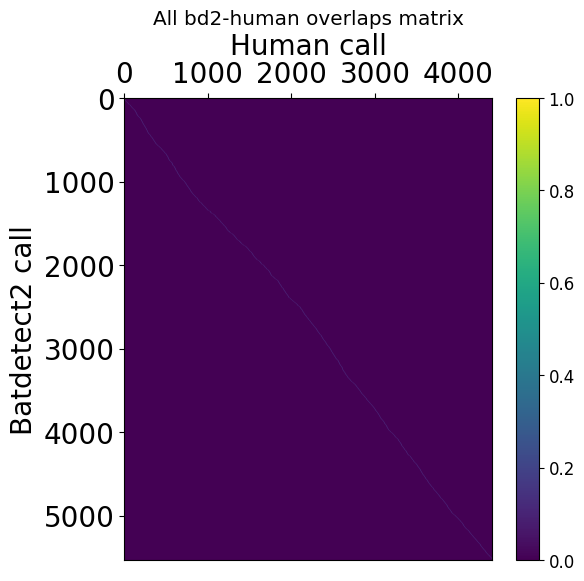

In [113]:
fig, ax = plt.subplots(1, 1, figsize=(6,6))
plt.rcParams.update({'font.size':12})

ax.set_title('All bd2-human overlaps matrix')
im = ax.imshow(association_matrix[np.logical_or.reduce(association_matrix, axis=1),:])
ax.set_xlabel('Human call')
ax.xaxis.set_label_position('top')
ax.set_ylabel('Batdetect2 call')
ax.tick_params(top=True, labeltop=True, bottom=False, labelbottom=False)
fig.colorbar(im, orientation='vertical')

plt.show()

In [131]:
batdetect2_subset = batdetect2_df_file[:].copy()
human_annotations_subset = bd2_human_df_file[:].copy()

dist_matrix = np.zeros((len(batdetect2_subset), len(human_annotations_subset)))
association_matrix = np.zeros((len(batdetect2_subset), len(human_annotations_subset)), dtype='bool')
collect_human = pd.DataFrame()
collect_bd2 = pd.DataFrame()
for index in range(len(human_annotations_subset)):
    human_row = human_annotations_subset.iloc[index]
    dist_to_all_calls = ((batdetect2_subset['peak_frequency_time_SPECTROGRAM'] - human_row['peak_frequency_time']).values)
    dist_matrix[:,index] = dist_to_all_calls
 
    dist_to_all_calls[np.abs(dist_to_all_calls)>=0.001] = 1
    dist_to_all_calls[np.abs(dist_to_all_calls)<0.001] = 0
    if np.abs(dist_to_all_calls-1).sum() > 1:
        collect_bd2 = pd.concat([collect_bd2, batdetect2_subset[dist_to_all_calls<0.5]])
        collect_human = pd.concat([collect_human, pd.DataFrame(human_row).T])

    association_matrix[:,index] = ~dist_to_all_calls.astype('bool')

human_bd2_true_positives = human_annotations_subset.loc[np.logical_or.reduce(association_matrix, axis=0)]
bd2_false_negatives = human_annotations_subset.loc[~(np.logical_or.reduce(association_matrix, axis=0))]
bd2_true_positives = batdetect2_subset.loc[np.logical_or.reduce(association_matrix, axis=1)]
bd2_false_positives = batdetect2_subset.loc[~(np.logical_or.reduce(association_matrix, axis=1))]
print(len(human_bd2_true_positives), len(bd2_false_negatives), len(bd2_true_positives), len(bd2_false_positives))

3893 513 5530 85923


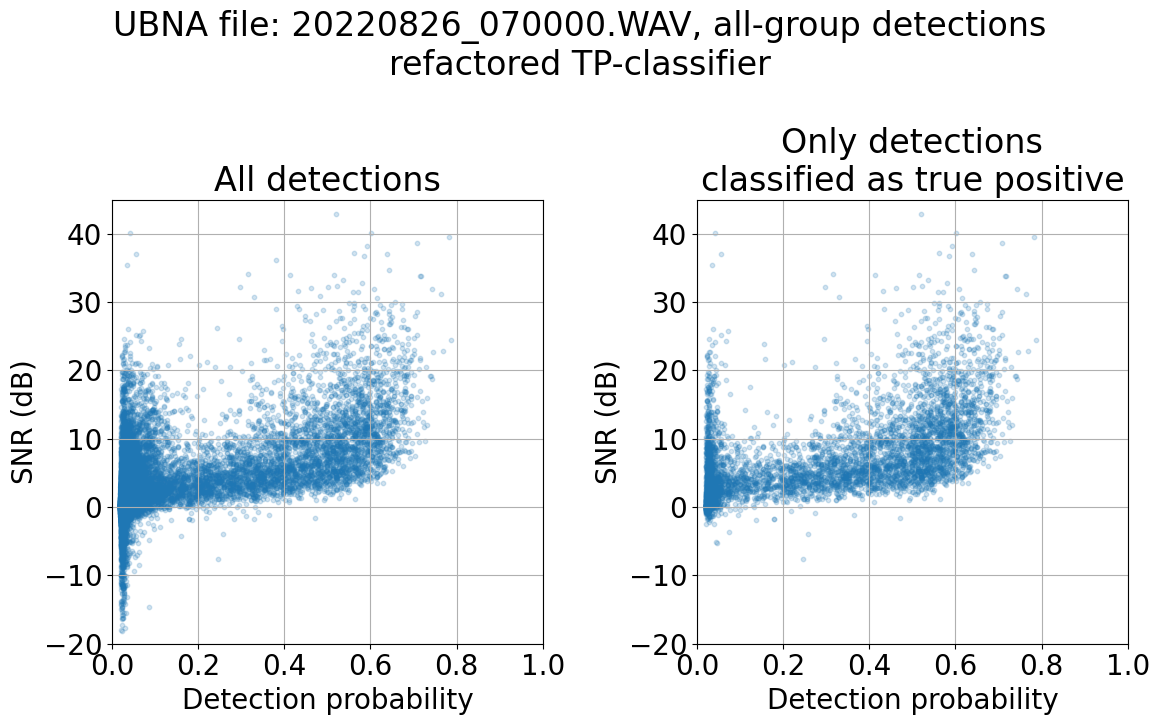

In [132]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,7.5))
plt.rcParams.update({'font.size':20})
fig.suptitle(f'UBNA file: {wav_filename}.WAV, all-group detections\nrefactored TP-classifier')

ax1.set_title(f'All detections')
ax1.scatter(batdetect2_df_file['det_prob'].values, batdetect2_df_file['SNR'].values,
            alpha=0.2, s=10)
ax1.grid(which='both')
ax1.set_xlabel('Detection probability')
ax1.set_ylabel('SNR (dB)')
ax1.set_xlim(0, 1.0)
ax1.set_ylim(-20, 45.0)

ax2.set_title(f'Only detections\nclassified as true positive')
ax2.scatter(bd2_true_positives['det_prob'].values, bd2_true_positives['SNR'].values,
            alpha=0.2, s=10)
ax2.grid(which='both')
ax2.set_xlabel('Detection probability')
ax2.set_ylabel('SNR (dB)')
ax2.set_xlim(0, 1.0)
ax2.set_ylim(-20, 45.0)

fig.tight_layout()
plt.show()

In [133]:
save_loc_reduced_overlaps = Path(f"bd2__{threshold_tag}_chunksize{int(args['chunk_size'])}_{wav_filename}_REDUCED_OVERLAPS.csv")
filepath_reduced_overlaps = bd2_dets_save_dir / save_loc_reduced_overlaps
batdetect2_df_file_reduced_overlaps = pd.read_csv(filepath_reduced_overlaps, sep=',', index_col=0)
batdetect2_df_file_reduced_overlaps.rename(columns={'KMEANS_CLASSES':'freq_group'}, inplace=True)

In [134]:
batdetect2_subset_reduced_overlaps = batdetect2_df_file_reduced_overlaps[:].copy()
dist_matrix = np.zeros((len(batdetect2_subset_reduced_overlaps), len(human_annotations_subset)))
association_matrix = np.zeros((len(batdetect2_subset_reduced_overlaps), len(human_annotations_subset)), dtype='bool')
collect_human = pd.DataFrame()
collect_bd2 = pd.DataFrame()
for index in range(len(batdetect2_subset_reduced_overlaps)):
    batdetect2_row = batdetect2_subset_reduced_overlaps.iloc[index]
    dist_to_all_calls = ((human_annotations_subset['peak_frequency_time'] - batdetect2_row['peak_frequency_time_SPECTROGRAM']).values)
    dist_matrix[index,:] = dist_to_all_calls
 
    dist_to_all_calls[np.abs(dist_to_all_calls)>=0.001] = 1
    dist_to_all_calls[np.abs(dist_to_all_calls)<0.001] = 0
    if np.abs(dist_to_all_calls-1).sum() > 1:
        collect_human = pd.concat([collect_human, human_annotations_subset[dist_to_all_calls<0.5]])
        collect_bd2 = pd.concat([collect_bd2, pd.DataFrame(batdetect2_row).T])

    association_matrix[index,:] = ~dist_to_all_calls.astype('bool')

human_bd2_true_positives_from_no_overlaps_data = human_annotations_subset.loc[np.logical_or.reduce(association_matrix, axis=0)]
bd2_false_negatives_from_no_overlaps_data = human_annotations_subset.loc[~(np.logical_or.reduce(association_matrix, axis=0))]
bd2_true_positives_from_no_overlaps_data = batdetect2_subset_reduced_overlaps.loc[np.logical_or.reduce(association_matrix, axis=1)]
bd2_false_positives_from_no_overlaps_data = batdetect2_subset_reduced_overlaps.loc[~(np.logical_or.reduce(association_matrix, axis=1))]
print(len(human_bd2_true_positives_from_no_overlaps_data), len(bd2_false_negatives_from_no_overlaps_data), 
      len(bd2_true_positives_from_no_overlaps_data), len(bd2_false_positives_from_no_overlaps_data))

3715 691 3709 56711


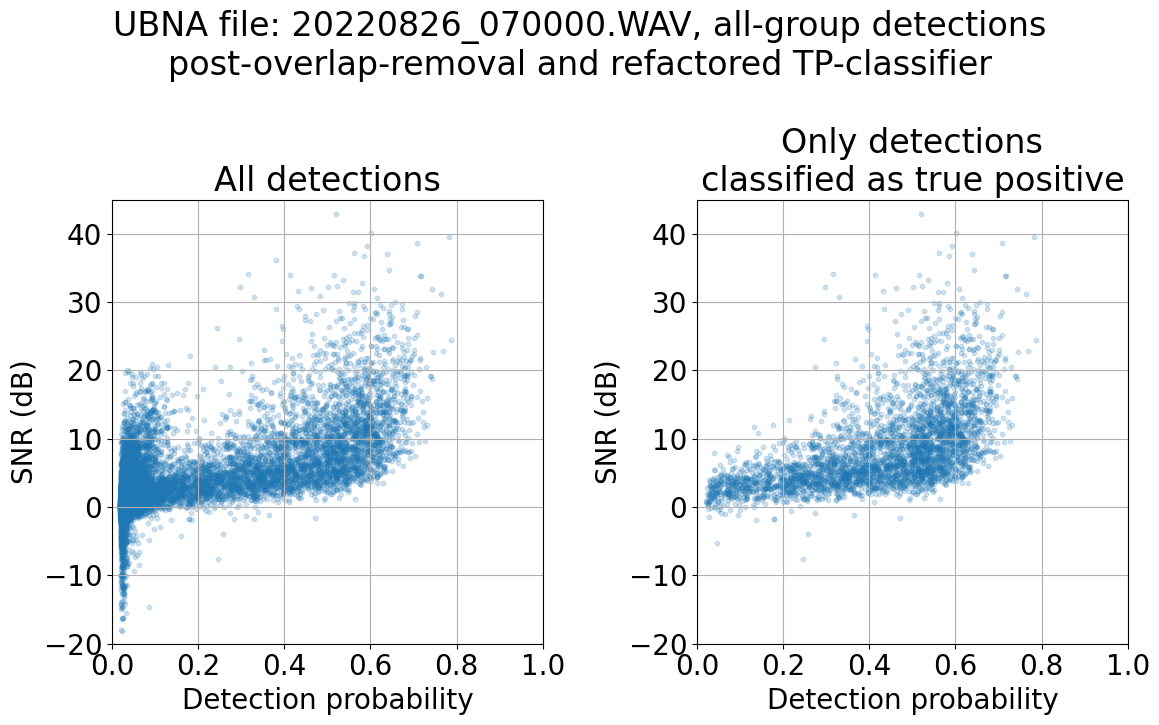

In [135]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,7.5))
plt.rcParams.update({'font.size':20})
fig.suptitle(f'UBNA file: {wav_filename}.WAV, all-group detections\npost-overlap-removal and refactored TP-classifier')

ax1.set_title(f'All detections')
ax1.scatter(batdetect2_df_file_reduced_overlaps['det_prob'].values, 
            batdetect2_df_file_reduced_overlaps['SNR'].values,
            alpha=0.2, s=10)
ax1.grid(which='both')
ax1.set_xlabel('Detection probability')
ax1.set_ylabel('SNR (dB)')
ax1.set_xlim(0, 1.0)
ax1.set_ylim(-20, 45.0)

ax2.set_title(f'Only detections\nclassified as true positive')
ax2.scatter(bd2_true_positives_from_no_overlaps_data['det_prob'].values, 
            bd2_true_positives_from_no_overlaps_data['SNR'].values,
            alpha=0.2, s=10)
ax2.grid(which='both')
ax2.set_xlabel('Detection probability')
ax2.set_ylabel('SNR (dB)')
ax2.set_xlim(0, 1.0)
ax2.set_ylim(-20, 45.0)

fig.tight_layout()
plt.show()

In [136]:
lf_batdetect2_subset = batdetect2_df_file[batdetect2_df_file['freq_group']=='LF'][:].copy()
lf_human_annotations_subset = bd2_human_df_file[bd2_human_df_file['freq_group']=='LF'][:].copy()

dist_matrix = np.zeros((len(lf_batdetect2_subset), len(lf_human_annotations_subset)))
association_matrix = np.zeros((len(lf_batdetect2_subset), len(lf_human_annotations_subset)), dtype='bool')
collect_human = pd.DataFrame()
collect_bd2 = pd.DataFrame()
for index in range(len(lf_human_annotations_subset)):
    human_row = lf_human_annotations_subset.iloc[index]
    dist_to_all_calls = ((lf_batdetect2_subset['peak_frequency_time_SPECTROGRAM'] - human_row['peak_frequency_time']).values)
    dist_matrix[:,index] = dist_to_all_calls
 
    dist_to_all_calls[np.abs(dist_to_all_calls)>=0.001] = 1
    dist_to_all_calls[np.abs(dist_to_all_calls)<0.001] = 0
    if np.abs(dist_to_all_calls-1).sum() > 1:
        collect_bd2 = pd.concat([collect_bd2, lf_batdetect2_subset[dist_to_all_calls<0.5]])
        collect_human = pd.concat([collect_human, pd.DataFrame(human_row).T])

    association_matrix[:,index] = ~dist_to_all_calls.astype('bool')

lf_human_bd2_true_positives = lf_human_annotations_subset.loc[np.logical_or.reduce(association_matrix, axis=0)]
lf_bd2_false_negatives = lf_human_annotations_subset.loc[~(np.logical_or.reduce(association_matrix, axis=0))]
lf_bd2_true_positives = lf_batdetect2_subset.loc[np.logical_or.reduce(association_matrix, axis=1)]
lf_bd2_false_positives = lf_batdetect2_subset.loc[~(np.logical_or.reduce(association_matrix, axis=1))]
print(len(lf_human_bd2_true_positives), len(lf_bd2_false_negatives), len(lf_bd2_true_positives), len(lf_bd2_false_positives))

798 340 826 45725


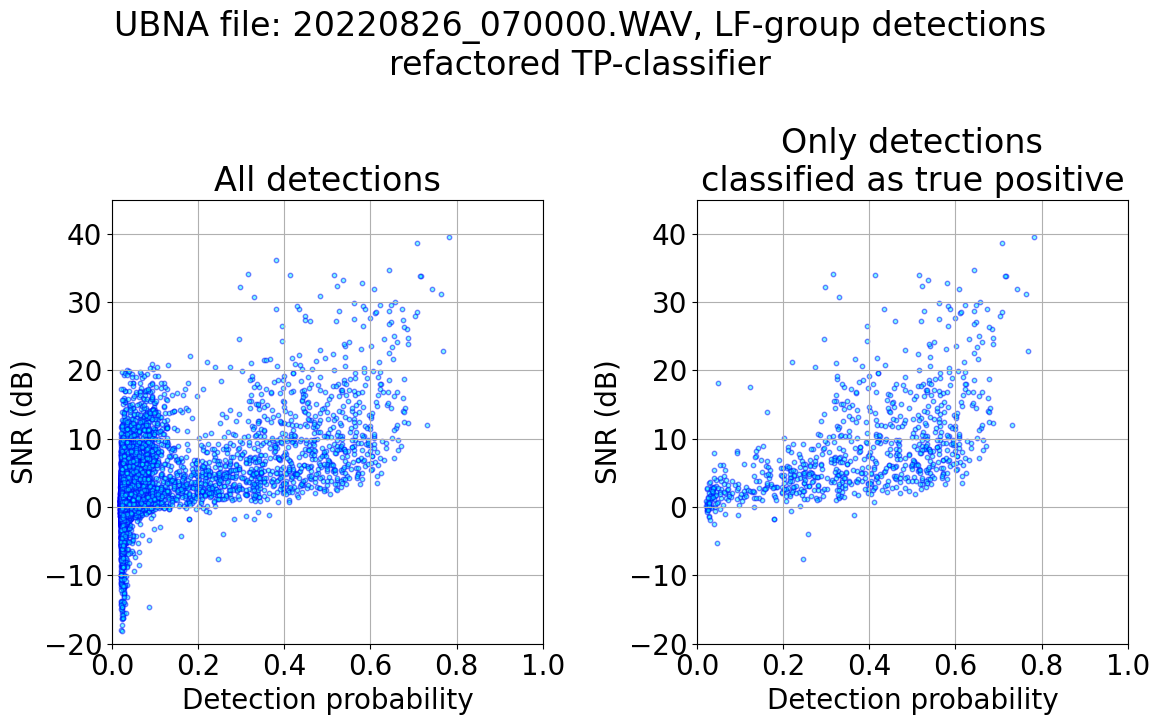

In [138]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 7.5))
plt.rcParams.update({'font.size':20})
fig.suptitle(f'UBNA file: {wav_filename}.WAV, LF-group detections\nrefactored TP-classifier')
ax1.set_title(f'All detections')
ax1.scatter(lf_batdetect2_subset['det_prob'].values, 
            lf_batdetect2_subset['SNR'].values,
            alpha=0.5, s=10, facecolor='cyan', edgecolor='blue')
ax1.grid(which='both')
ax1.set_xlabel('Detection probability')
ax1.set_ylabel('SNR (dB)')
ax1.set_xlim(0, 1.0)
ax1.set_ylim(-20, 45.0)

ax2.set_title(f'Only detections\nclassified as true positive')
ax2.scatter(lf_bd2_true_positives['det_prob'].values, lf_bd2_true_positives['SNR'].values,
            alpha=0.5, s=10, facecolor='cyan', edgecolor='blue')
ax2.grid(which='both')
ax2.set_xlabel('Detection probability')
ax2.set_ylabel('SNR (dB)')
ax2.set_xlim(0, 1.0)
ax2.set_ylim(-20, 45.0)

fig.tight_layout()
plt.show()

In [139]:
lf_batdetect2_subset_reduced_overlaps = batdetect2_df_file_reduced_overlaps[batdetect2_df_file_reduced_overlaps['freq_group']=='LF'][:].copy()
dist_matrix = np.zeros((len(lf_batdetect2_subset_reduced_overlaps), len(lf_human_annotations_subset)))
association_matrix = np.zeros((len(lf_batdetect2_subset_reduced_overlaps), len(lf_human_annotations_subset)), dtype='bool')
collect_human = pd.DataFrame()
collect_bd2 = pd.DataFrame()
for index in range(len(lf_batdetect2_subset_reduced_overlaps)):
    batdetect2_row = lf_batdetect2_subset_reduced_overlaps.iloc[index]
    dist_to_all_calls = ((lf_human_annotations_subset['peak_frequency_time'] - batdetect2_row['peak_frequency_time_SPECTROGRAM']).values)
    dist_matrix[index,:] = dist_to_all_calls
 
    dist_to_all_calls[np.abs(dist_to_all_calls)>=0.001] = 1
    dist_to_all_calls[np.abs(dist_to_all_calls)<0.001] = 0
    if np.abs(dist_to_all_calls-1).sum() > 1:
        collect_human = pd.concat([collect_human, lf_human_annotations_subset[dist_to_all_calls<0.5]])
        collect_bd2 = pd.concat([collect_bd2, pd.DataFrame(batdetect2_row).T])

    association_matrix[index,:] = ~dist_to_all_calls.astype('bool')

lf_human_bd2_true_positives_from_no_overlaps_data = lf_human_annotations_subset.loc[np.logical_or.reduce(association_matrix, axis=0)]
lf_bd2_false_negatives_from_no_overlaps_data = lf_human_annotations_subset.loc[~(np.logical_or.reduce(association_matrix, axis=0))]
lf_bd2_true_positives_from_no_overlaps_data = lf_batdetect2_subset_reduced_overlaps.loc[np.logical_or.reduce(association_matrix, axis=1)]
lf_bd2_false_positives_from_no_overlaps_data = lf_batdetect2_subset_reduced_overlaps.loc[~(np.logical_or.reduce(association_matrix, axis=1))]
print(len(lf_human_bd2_true_positives_from_no_overlaps_data), len(lf_bd2_false_negatives_from_no_overlaps_data), 
      len(lf_bd2_true_positives_from_no_overlaps_data), len(lf_bd2_false_positives_from_no_overlaps_data))

757 381 757 33107


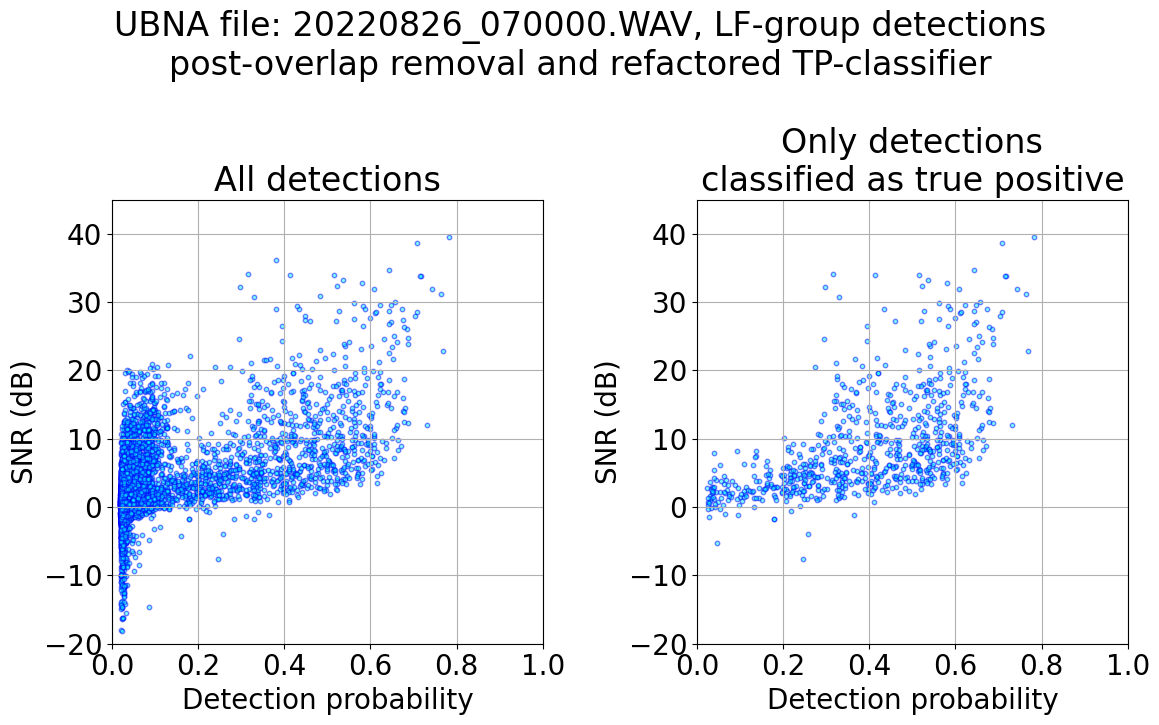

In [143]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,7.5))
plt.rcParams.update({'font.size':20})
fig.suptitle(f'UBNA file: {wav_filename}.WAV, LF-group detections\npost-overlap removal and refactored TP-classifier')
ax1.set_title(f'All detections')
ax1.scatter(lf_batdetect2_subset_reduced_overlaps['det_prob'].values, 
            lf_batdetect2_subset_reduced_overlaps['SNR'].values,
            alpha=0.5, s=10, facecolor='cyan', edgecolor='blue')
ax1.grid(which='both')
ax1.set_xlabel('Detection probability')
ax1.set_ylabel('SNR (dB)')
ax1.set_xlim(0, 1.0)
ax1.set_ylim(-20, 45.0)

ax2.set_title(f'Only detections\nclassified as true positive')
ax2.scatter(lf_bd2_true_positives_from_no_overlaps_data['det_prob'].values, 
            lf_bd2_true_positives_from_no_overlaps_data['SNR'].values,
            alpha=0.5, s=10, facecolor='cyan', edgecolor='blue')
ax2.grid(which='both')
ax2.set_xlabel('Detection probability')
ax2.set_ylabel('SNR (dB)')
ax2.set_xlim(0, 1.0)
ax2.set_ylim(-20, 45.0)

fig.tight_layout()
plt.show()

In [146]:
hf_batdetect2_subset = batdetect2_df_file[batdetect2_df_file['freq_group']=='HF'][:].copy()
hf_human_annotations_subset = bd2_human_df_file[bd2_human_df_file['freq_group']=='HF'][:].copy()

dist_matrix = np.zeros((len(hf_batdetect2_subset), len(hf_human_annotations_subset)))
association_matrix = np.zeros((len(hf_batdetect2_subset), len(hf_human_annotations_subset)), dtype='bool')
collect_human = pd.DataFrame()
collect_bd2 = pd.DataFrame()
for index in range(len(hf_human_annotations_subset)):
    human_row = hf_human_annotations_subset.iloc[index]
    dist_to_all_calls = ((hf_batdetect2_subset['peak_frequency_time_SPECTROGRAM'] - human_row['peak_frequency_time']).values)
    dist_matrix[:,index] = dist_to_all_calls
 
    dist_to_all_calls[np.abs(dist_to_all_calls)>=0.001] = 1
    dist_to_all_calls[np.abs(dist_to_all_calls)<0.001] = 0
    if np.abs(dist_to_all_calls-1).sum() > 1:
        collect_bd2 = pd.concat([collect_bd2, hf_batdetect2_subset[dist_to_all_calls<0.5]])
        collect_human = pd.concat([collect_human, pd.DataFrame(human_row).T])

    association_matrix[:,index] = ~dist_to_all_calls.astype('bool')

hf_human_bd2_true_positives = hf_human_annotations_subset.loc[np.logical_or.reduce(association_matrix, axis=0)]
hf_bd2_false_negatives = hf_human_annotations_subset.loc[~(np.logical_or.reduce(association_matrix, axis=0))]
hf_bd2_true_positives = hf_batdetect2_subset.loc[np.logical_or.reduce(association_matrix, axis=1)]
hf_bd2_false_positives = hf_batdetect2_subset.loc[~(np.logical_or.reduce(association_matrix, axis=1))]
print(len(hf_human_bd2_true_positives), len(hf_bd2_false_negatives), len(hf_bd2_true_positives), len(hf_bd2_false_positives))

3035 233 4243 40659


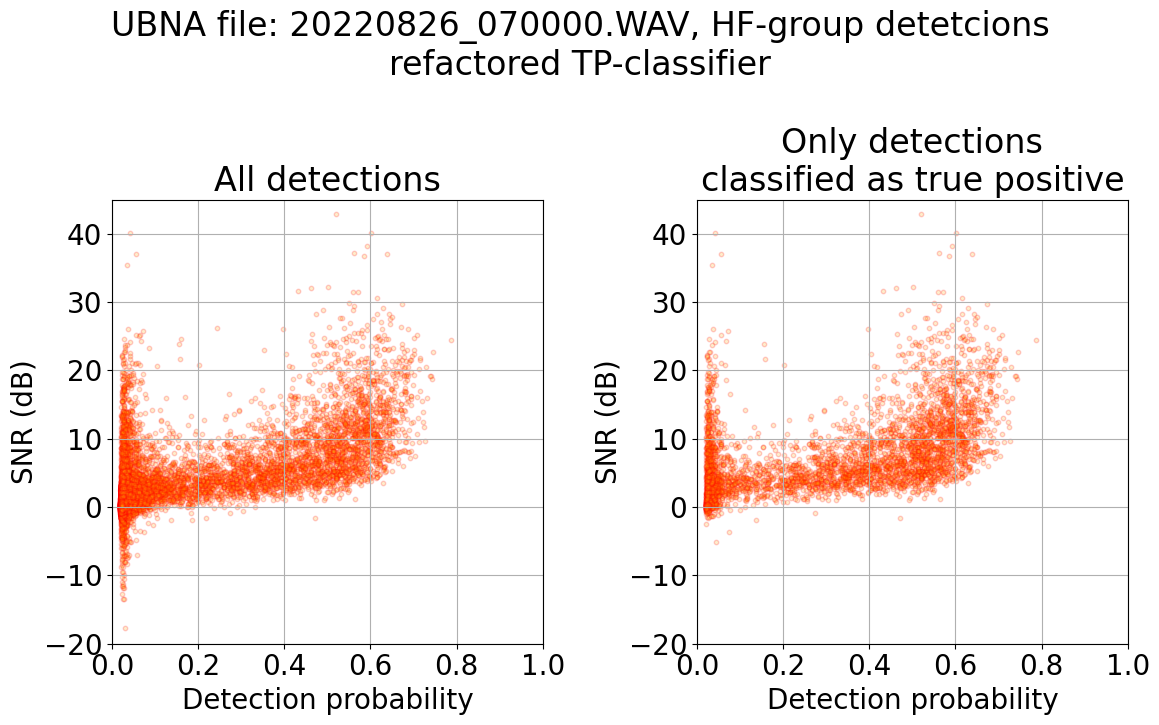

In [148]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,7.5))
plt.rcParams.update({'font.size':20})
fig.suptitle(f'UBNA file: {wav_filename}.WAV, HF-group detetcions\nrefactored TP-classifier')
ax1.set_title(f'All detections')
ax1.scatter(hf_batdetect2_subset['det_prob'].values, hf_batdetect2_subset['SNR'].values,
            alpha=0.2, s=10, facecolor='orange', edgecolor='red')
ax1.grid(which='both')
ax1.set_xlabel('Detection probability')
ax1.set_ylabel('SNR (dB)')
ax1.set_xlim(0, 1.0)
ax1.set_ylim(-20, 45.0)

ax2.set_title(f'Only detections\nclassified as true positive')
ax2.scatter(hf_bd2_true_positives['det_prob'].values, hf_bd2_true_positives['SNR'].values,
            alpha=0.2, s=10, facecolor='orange', edgecolor='red')
ax2.grid(which='both')
ax2.set_xlabel('Detection probability')
ax2.set_ylabel('SNR (dB)')
ax2.set_xlim(0, 1.0)
ax2.set_ylim(-20, 45.0)

fig.tight_layout()
plt.show()

In [149]:
hf_batdetect2_subset_reduced_overlaps = batdetect2_df_file_reduced_overlaps[batdetect2_df_file_reduced_overlaps['freq_group']=='HF'][:].copy()
dist_matrix = np.zeros((len(hf_batdetect2_subset_reduced_overlaps), len(hf_human_annotations_subset)))
association_matrix = np.zeros((len(hf_batdetect2_subset_reduced_overlaps), len(hf_human_annotations_subset)), dtype='bool')
collect_human = pd.DataFrame()
collect_bd2 = pd.DataFrame()
for index in range(len(hf_batdetect2_subset_reduced_overlaps)):
    batdetect2_row = hf_batdetect2_subset_reduced_overlaps.iloc[index]
    dist_to_all_calls = ((hf_human_annotations_subset['peak_frequency_time'] - batdetect2_row['peak_frequency_time_SPECTROGRAM']).values)
    dist_matrix[index,:] = dist_to_all_calls
 
    dist_to_all_calls[np.abs(dist_to_all_calls)>=0.001] = 1
    dist_to_all_calls[np.abs(dist_to_all_calls)<0.001] = 0
    if np.abs(dist_to_all_calls-1).sum() > 1:
        collect_human = pd.concat([collect_human, hf_human_annotations_subset[dist_to_all_calls<0.5]])
        collect_bd2 = pd.concat([collect_bd2, pd.DataFrame(batdetect2_row).T])

    association_matrix[index,:] = ~dist_to_all_calls.astype('bool')

hf_human_bd2_true_positives_from_no_overlaps_data = hf_human_annotations_subset.loc[np.logical_or.reduce(association_matrix, axis=0)]
hf_bd2_false_negatives_from_no_overlaps_data = hf_human_annotations_subset.loc[~(np.logical_or.reduce(association_matrix, axis=0))]
hf_bd2_true_positives_from_no_overlaps_data = hf_batdetect2_subset_reduced_overlaps.loc[np.logical_or.reduce(association_matrix, axis=1)]
hf_bd2_false_positives_from_no_overlaps_data = hf_batdetect2_subset_reduced_overlaps.loc[~(np.logical_or.reduce(association_matrix, axis=1))]
print(len(hf_human_bd2_true_positives_from_no_overlaps_data), len(hf_bd2_false_negatives_from_no_overlaps_data), 
      len(hf_bd2_true_positives_from_no_overlaps_data), len(hf_bd2_false_positives_from_no_overlaps_data))

2941 327 2941 23615


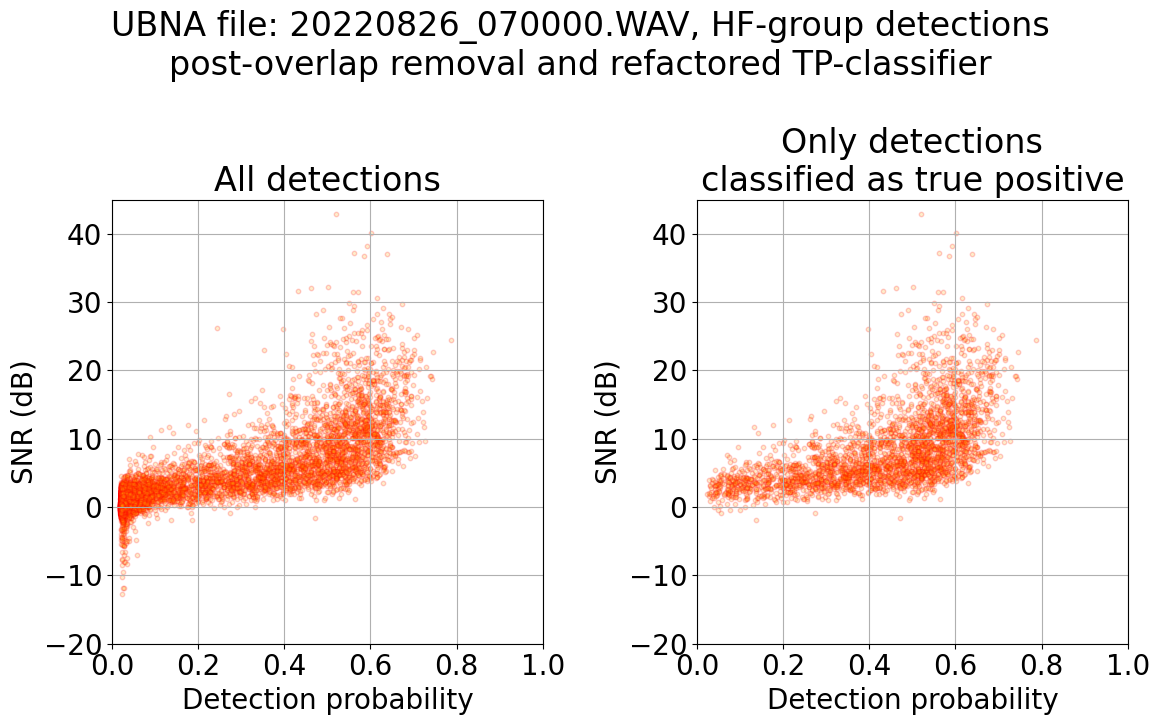

In [151]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,7.5))
plt.rcParams.update({'font.size':20})
fig.suptitle(f'UBNA file: {wav_filename}.WAV, HF-group detections\npost-overlap removal and refactored TP-classifier')
ax1.set_title(f'All detections')
ax1.scatter(hf_batdetect2_subset_reduced_overlaps['det_prob'].values, 
            hf_batdetect2_subset_reduced_overlaps['SNR'].values,
            alpha=0.2, s=10, facecolor='orange', edgecolor='red')
ax1.grid(which='both')
ax1.set_xlabel('Detection probability')
ax1.set_ylabel('SNR (dB)')
ax1.set_xlim(0, 1.0)
ax1.set_ylim(-20, 45.0)

ax2.set_title(f'Only detections\nclassified as true positive')
ax2.scatter(hf_bd2_true_positives_from_no_overlaps_data['det_prob'].values, 
            hf_bd2_true_positives_from_no_overlaps_data['SNR'].values,
            alpha=0.2, s=10, facecolor='orange', edgecolor='red')
ax2.grid(which='both')
ax2.set_xlabel('Detection probability')
ax2.set_ylabel('SNR (dB)')
ax2.set_xlim(0, 1.0)
ax2.set_ylim(-20, 45.0)

fig.tight_layout()
plt.show()

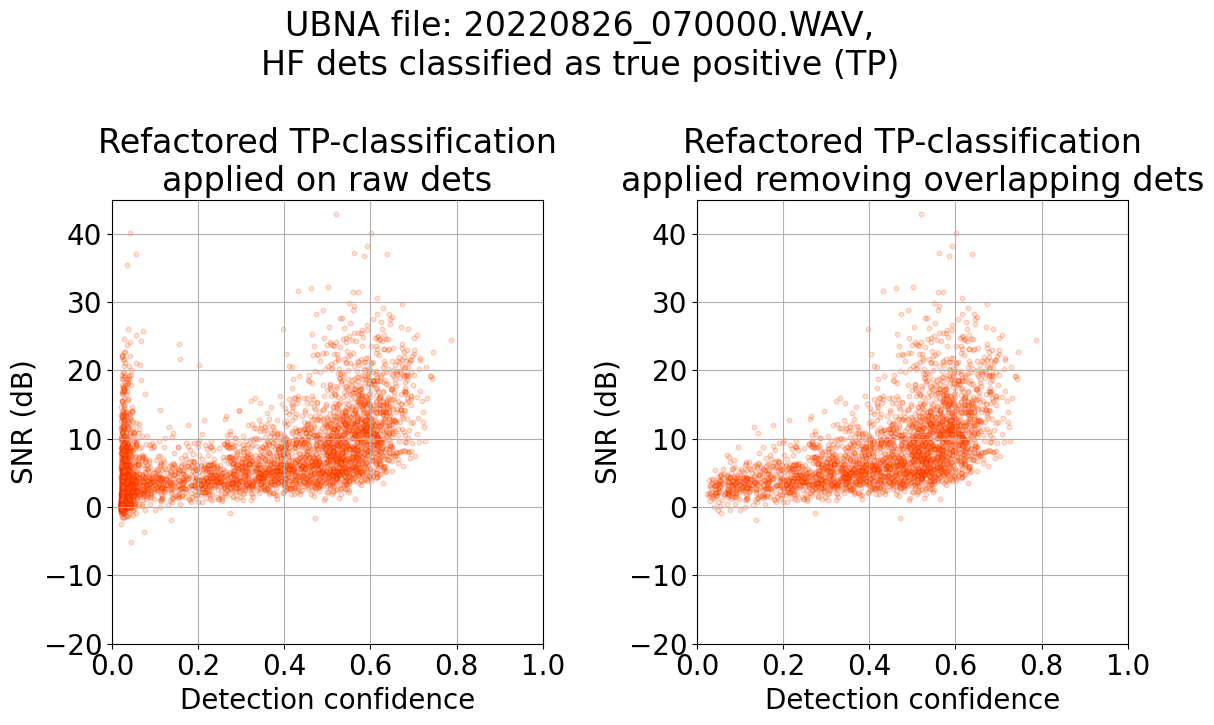

In [157]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,7.5))
plt.rcParams.update({'font.size':20})
fig.suptitle(f'UBNA file: {wav_filename}.WAV,\nHF dets classified as true positive (TP)')
ax1.set_title(f'Refactored TP-classification\napplied on raw dets')
ax1.scatter(hf_bd2_true_positives['det_prob'].values, 
            hf_bd2_true_positives['SNR'].values,
            alpha=0.2, s=10, facecolor='orange', edgecolor='red')
ax1.grid(which='both')
ax1.set_xlabel('Detection confidence')
ax1.set_ylabel('SNR (dB)')
ax1.set_xlim(0, 1.0)
ax1.set_ylim(-20, 45.0)

ax2.set_title(f'Refactored TP-classification\napplied removing overlapping dets')
ax2.scatter(hf_bd2_true_positives_from_no_overlaps_data['det_prob'].values, 
            hf_bd2_true_positives_from_no_overlaps_data['SNR'].values,
            alpha=0.2, s=10, facecolor='orange', edgecolor='red')
ax2.grid(which='both')
ax2.set_xlabel('Detection confidence')
ax2.set_ylabel('SNR (dB)')
ax2.set_xlim(0, 1.0)
ax2.set_ylim(-20, 45.0)

fig.tight_layout()
plt.show()

In [158]:
hf_bd2_true_positives

,freq_group,peak_frequency_time_SPECTROGRAM,peak_frequency_SPECTROGRAM,peak_frequency_WELCH,SNR,start_time,end_time,low_freq,high_freq,class,class_prob,det_prob,individual,event,sampling_rate,input_file
63,HF,1.732900,47250.0,47040.0,3.570422,1.7295,1.7371,46953,51351,Pipistrellus pipistrellus,0.388,0.428,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...
154,HF,3.773733,46500.0,46080.0,6.879404,3.7705,3.7771,45234,54096,Pipistrellus pipistrellus,0.466,0.512,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...
164,HF,3.914267,47250.0,46080.0,8.649871,3.9105,3.9154,45234,59565,Pipistrellus pipistrellus,0.266,0.355,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...
169,HF,4.045500,52500.0,48000.0,2.673958,4.0445,4.0510,46953,53999,Pipistrellus pipistrellus,0.046,0.048,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...
179,HF,4.166333,48000.0,48000.0,3.463646,4.1625,4.1685,45234,59329,Pipistrellus pipistrellus,0.218,0.312,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91138,HF,1787.779767,39750.0,39360.0,9.656562,1787.7745,1787.7849,37500,46675,Pipistrellus nathusii,0.492,0.587,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...
91144,HF,1787.964100,40500.0,40320.0,6.562988,1787.9595,1787.9694,37500,45913,Pipistrellus nathusii,0.537,0.591,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...
91157,HF,1788.217133,40500.0,41280.0,8.990165,1788.2125,1788.2212,39218,48186,Pipistrellus nathusii,0.431,0.544,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...
91166,HF,1788.419000,41250.0,41280.0,5.583953,1788.4135,1788.4225,40078,49982,Pipistrellus nathusii,0.441,0.566,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...


In [159]:
hf_bd2_true_positives_from_no_overlaps_data

,freq_group,peak_frequency_time_SPECTROGRAM,peak_frequency_SPECTROGRAM,peak_frequency_WELCH,SNR,start_time,end_time,low_freq,high_freq,class,class_prob,det_prob,individual,event,sampling_rate,input_file
63,HF,1.732900,47250.0,47040.0,3.570422,1.7295,1.7371,46953,51351,Pipistrellus pipistrellus,0.388,0.428,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...
154,HF,3.773733,46500.0,46080.0,6.879404,3.7705,3.7771,45234,54096,Pipistrellus pipistrellus,0.466,0.512,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...
164,HF,3.914267,47250.0,46080.0,8.649871,3.9105,3.9154,45234,59565,Pipistrellus pipistrellus,0.266,0.355,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...
169,HF,4.045500,52500.0,48000.0,2.673958,4.0445,4.0510,46953,53999,Pipistrellus pipistrellus,0.046,0.048,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...
179,HF,4.166333,48000.0,48000.0,3.463646,4.1625,4.1685,45234,59329,Pipistrellus pipistrellus,0.218,0.312,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91138,HF,1787.779767,39750.0,39360.0,9.656562,1787.7745,1787.7849,37500,46675,Pipistrellus nathusii,0.492,0.587,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...
91144,HF,1787.964100,40500.0,40320.0,6.562988,1787.9595,1787.9694,37500,45913,Pipistrellus nathusii,0.537,0.591,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...
91157,HF,1788.217133,40500.0,41280.0,8.990165,1788.2125,1788.2212,39218,48186,Pipistrellus nathusii,0.431,0.544,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...
91166,HF,1788.419000,41250.0,41280.0,5.583953,1788.4135,1788.4225,40078,49982,Pipistrellus nathusii,0.441,0.566,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...


In [167]:
merged_df = pd.merge(lf_bd2_true_positives, lf_bd2_true_positives_from_no_overlaps_data, 
                     on=list(lf_bd2_true_positives.columns), how='outer', indicator=True)
merged_df.head(10)

,freq_group,peak_frequency_time_SPECTROGRAM,peak_frequency_SPECTROGRAM,peak_frequency_WELCH,SNR,start_time,end_time,low_freq,high_freq,class,class_prob,det_prob,individual,event,sampling_rate,input_file,_merge
0,LF,31.196967,24750.0,24000.0,1.052236,31.1865,31.2022,23750,29512,Nyctalus leisleri,0.138,0.322,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...,both
1,LF,32.199700,22500.0,23040.0,0.781188,32.1895,32.2008,23750,30161,Nyctalus leisleri,0.017,0.049,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...,both
2,LF,32.622300,26250.0,25920.0,5.033592,32.6175,32.6342,24609,28640,Nyctalus leisleri,0.365,0.571,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...,both
3,LF,33.093733,25500.0,25920.0,3.818196,33.0855,33.1011,24609,28287,Nyctalus leisleri,0.215,0.370,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...,both
4,LF,33.496567,25500.0,25920.0,4.136854,33.4915,33.5056,24609,28405,Nyctalus leisleri,0.234,0.416,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...,both
5,LF,33.788467,24000.0,24960.0,4.613169,33.7805,33.7987,24609,28572,Nyctalus leisleri,0.118,0.226,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...,both
6,LF,34.652033,24000.0,24960.0,2.959256,34.6315,34.6523,23750,27664,Nyctalus leisleri,0.048,0.114,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...,both
7,LF,36.790733,25500.0,25920.0,8.441227,36.7825,36.7981,24609,29404,Nyctalus leisleri,0.433,0.532,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...,both
8,LF,37.039967,24000.0,25920.0,12.882807,37.0215,37.0432,24609,28610,Nyctalus leisleri,0.235,0.360,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...,both
9,LF,37.039733,24000.0,24000.0,5.139569,37.0345,37.0496,23750,26880,Nyctalus leisleri,0.116,0.152,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...,left_only


In [168]:
uncommon_left_rows = merged_df[merged_df['_merge'] == 'left_only'].reset_index(drop=True)
common_rows = merged_df[merged_df['_merge'] == 'both'].reset_index(drop=True)
uncommon_right_rows = merged_df[merged_df['_merge'] == 'right_only'].reset_index(drop=True)
uncommon_left_rows.head(10)

,freq_group,peak_frequency_time_SPECTROGRAM,peak_frequency_SPECTROGRAM,peak_frequency_WELCH,SNR,start_time,end_time,low_freq,high_freq,class,class_prob,det_prob,individual,event,sampling_rate,input_file,_merge
0,LF,37.039733,24000.0,24000.0,5.139569,37.0345,37.0496,23750,26880,Nyctalus leisleri,0.116,0.152,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...,left_only
1,LF,39.817467,23250.0,24000.0,5.376568,39.8075,39.8237,23750,27076,Nyctalus leisleri,0.170,0.215,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...,left_only
2,LF,39.816667,38250.0,40320.0,0.059535,39.8145,39.8210,32343,43280,Myotis daubentonii,0.012,0.023,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...,left_only
3,LF,40.558433,24750.0,24960.0,2.702806,40.5545,40.5674,22890,27039,Nyctalus leisleri,0.033,0.057,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...,left_only
4,LF,43.120000,24750.0,24960.0,3.053107,43.1165,43.1275,23750,28624,Nyctalus leisleri,0.020,0.044,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...,left_only
5,LF,43.395633,24000.0,24000.0,8.906367,43.3845,43.4042,23750,27196,Nyctalus leisleri,0.099,0.154,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...,left_only
6,LF,48.628300,24000.0,24000.0,6.115053,48.6235,48.6367,22890,26342,Nyctalus leisleri,0.041,0.061,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...,left_only
7,LF,50.320167,25500.0,24960.0,8.676091,50.3155,50.3335,23750,26662,Nyctalus leisleri,0.118,0.142,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...,left_only
8,LF,160.447867,27000.0,26880.0,6.871527,160.4325,160.4503,26328,30888,Nyctalus leisleri,0.081,0.149,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...,left_only
9,LF,169.102167,24750.0,25920.0,17.615709,169.0915,169.1070,24609,28517,Nyctalus leisleri,0.085,0.123,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...,left_only


In [162]:
uncommon_left_ravenpro_df = convert_bd2df_ravenpro(uncommon_left_rows)
uncommon_left_ravenpro_df.to_csv(f'20250122__20220826_070000_HF_true_positive_dets_no_overlap_reduction.txt', sep=sep, index=False)

In [169]:
uncommon_right_rows.head(10)

,freq_group,peak_frequency_time_SPECTROGRAM,peak_frequency_SPECTROGRAM,peak_frequency_WELCH,SNR,start_time,end_time,low_freq,high_freq,class,class_prob,det_prob,individual,event,sampling_rate,input_file,_merge


In [164]:
uncommon_right_ravenpro_df = convert_bd2df_ravenpro(uncommon_right_rows)
uncommon_right_ravenpro_df.to_csv(f'20250122__20220826_070000_HF_true_positive_dets_after_overlap_reduction.txt', sep=sep, index=False)

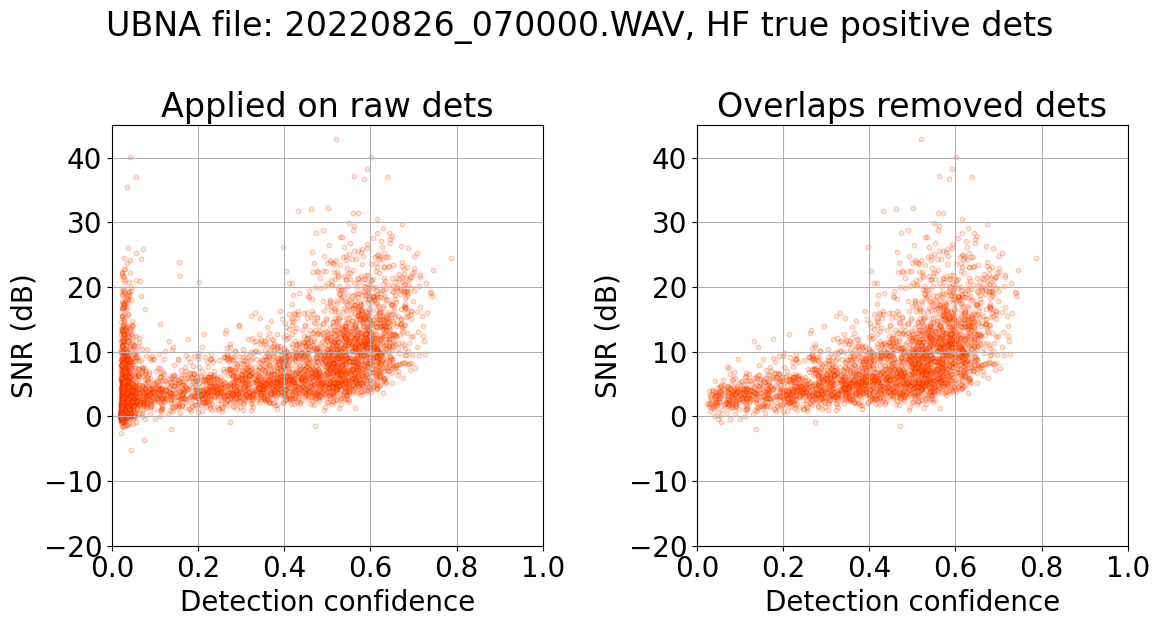

In [165]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,6.5))
plt.rcParams.update({'font.size':20})
fig.suptitle(f'UBNA file: {wav_filename}.WAV, HF true positive dets')
ax1.set_title(f'Applied on raw dets')
ax1.scatter(hf_bd2_true_positives['det_prob'].values, 
            hf_bd2_true_positives['SNR'].values,
            alpha=0.2, s=10, facecolor='orange', edgecolor='red')
ax1.grid(which='both')
ax1.set_xlabel('Detection confidence')
ax1.set_ylabel('SNR (dB)')
ax1.set_xlim(0, 1.0)
ax1.set_ylim(-20, 45.0)

ax2.set_title(f'Overlaps removed dets')
ax2.scatter(hf_bd2_true_positives_from_no_overlaps_data['det_prob'].values, 
            hf_bd2_true_positives_from_no_overlaps_data['SNR'].values,
            alpha=0.2, s=10, facecolor='orange', edgecolor='red')
ax2.grid(which='both')
ax2.set_xlabel('Detection confidence')
ax2.set_ylabel('SNR (dB)')
ax2.set_xlim(0, 1.0)
ax2.set_ylim(-20, 45.0)

fig.tight_layout()
plt.show()

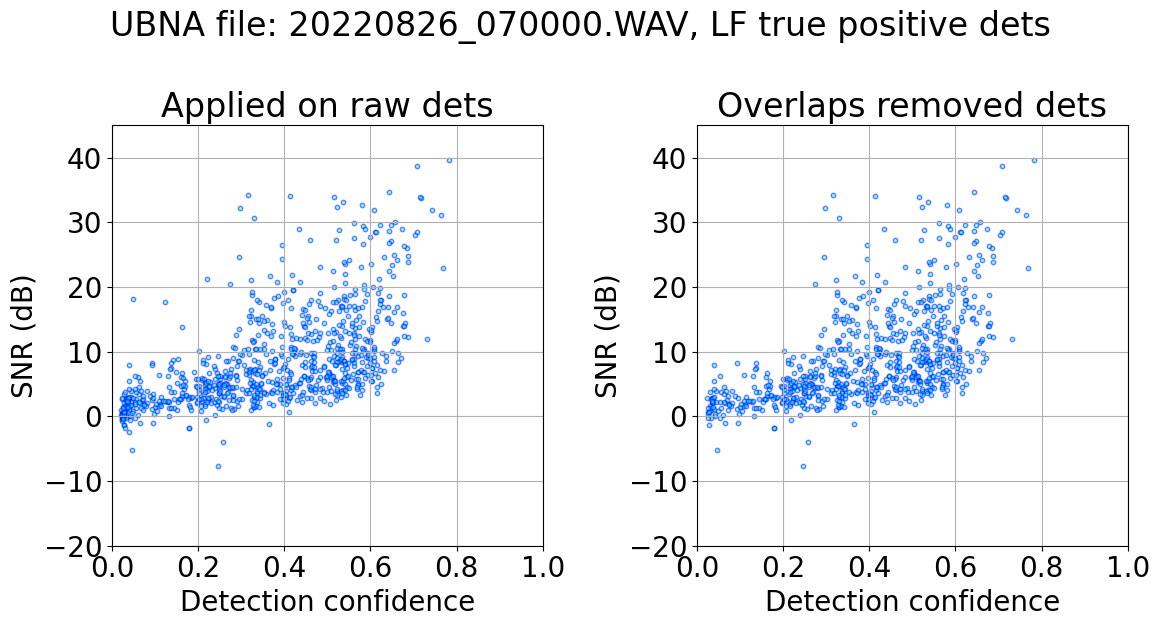

In [171]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,6.5))
plt.rcParams.update({'font.size':20})
fig.suptitle(f'UBNA file: {wav_filename}.WAV, LF true positive dets')
ax1.set_title(f'Applied on raw dets')
ax1.scatter(lf_bd2_true_positives['det_prob'].values, 
            lf_bd2_true_positives['SNR'].values,
            alpha=0.5, s=10, facecolor='cyan', edgecolor='blue')
ax1.grid(which='both')
ax1.set_xlabel('Detection confidence')
ax1.set_ylabel('SNR (dB)')
ax1.set_xlim(0, 1.0)
ax1.set_ylim(-20, 45.0)

ax2.set_title(f'Overlaps removed dets')
ax2.scatter(lf_bd2_true_positives_from_no_overlaps_data['det_prob'].values, 
            lf_bd2_true_positives_from_no_overlaps_data['SNR'].values,
            alpha=0.5, s=10, facecolor='cyan', edgecolor='blue')
ax2.grid(which='both')
ax2.set_xlabel('Detection confidence')
ax2.set_ylabel('SNR (dB)')
ax2.set_xlim(0, 1.0)
ax2.set_ylim(-20, 45.0)

fig.tight_layout()
plt.show()

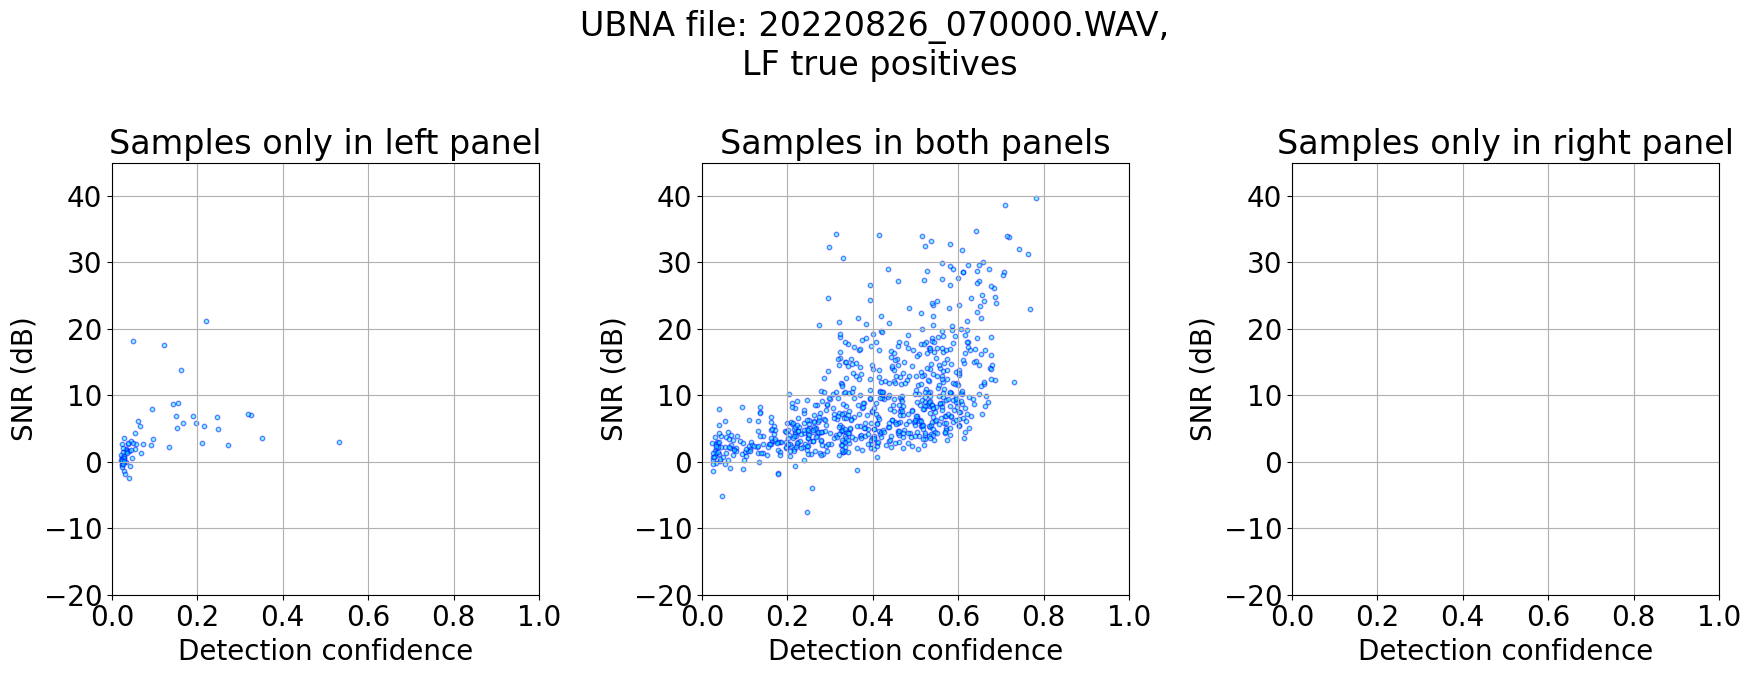

In [173]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18,7))
plt.rcParams.update({'font.size':20})
fig.suptitle(f'UBNA file: {wav_filename}.WAV, \nLF true positives')
ax1.set_title('Samples only in left panel')
ax1.scatter(uncommon_left_rows['det_prob'].values, 
            uncommon_left_rows['SNR'].values,
            alpha=0.5, s=10, facecolor='cyan', edgecolor='blue')
ax1.grid(which='both')
ax1.set_xlabel('Detection confidence')
ax1.set_ylabel('SNR (dB)')
ax1.set_xlim(0, 1.0)
ax1.set_ylim(-20, 45.0)

ax2.set_title('Samples in both panels')
ax2.scatter(common_rows['det_prob'].values, 
            common_rows['SNR'].values,
            alpha=0.5, s=10, facecolor='cyan', edgecolor='blue')
ax2.grid(which='both')
ax2.set_xlabel('Detection confidence')
ax2.set_ylabel('SNR (dB)')
ax2.set_xlim(0, 1.0)
ax2.set_ylim(-20, 45.0)

ax3.set_title('Samples only in right panel')
ax3.scatter(uncommon_right_rows['det_prob'].values, 
            uncommon_right_rows['SNR'].values,
            alpha=0.5, s=10, facecolor='cyan', edgecolor='blue')
ax3.grid(which='both')
ax3.set_xlabel('Detection confidence')
ax3.set_ylabel('SNR (dB)')
ax3.set_xlim(0, 1.0)
ax3.set_ylim(-20, 45.0)

fig.tight_layout()
plt.show()

In [200]:
all_files_batdetct2_df_reduced_overlaps = pd.DataFrame()
lf_all_files_batdetct2_df_reduced_overlaps = pd.DataFrame()
hf_all_files_batdetct2_df_reduced_overlaps = pd.DataFrame()

all_files_batdetct2_df_true_positives_reduced_overlaps = pd.DataFrame()
lf_all_files_batdetct2_df_true_positives_reduced_overlaps = pd.DataFrame()
hf_all_files_batdetct2_df_true_positives_reduced_overlaps = pd.DataFrame()
for file_num, file_key in enumerate(file_keys):
    wav_filename = file_key
    site = file_sites[file_key]
    plot_file = Path(f'{raventxt_human_files_dir}/{wav_filename}.WAV')
    raventxt_human_filename = f'{wav_filename}_manually_verified_by_AK_with_groups'

    snr_included_ravenpro_human_txt = pd.read_csv(f'{raventxt_human_files_dir}/{raventxt_human_filename}_ravenpro_SNR_aditya_SNR_and_peakfreqtime.txt', sep=sep)
    bd2_human_df_file = snr_included_ravenpro_human_txt.copy()
    bd2_human_df_file = bd2_human_df_file.drop(columns=['Selection', 'View', 'Channel'])
    bd2_human_df_file.rename(columns={'Begin Time (s)':'start_time',
                                'End Time (s)':'end_time',
                                'Low Freq (Hz)':'low_freq',
                                'High Freq (Hz)':'high_freq',
                                'Delta Time (s)':'delta_time_s',
                                'Manually-Verified Phonic Group':'freq_group',
                                'SNR NIST Quick (dB)':'snr_nist_quick_dB'}, inplace=True)
    bd2_human_df_file.sort_values('start_time', inplace=True)
    bd2_human_df_file = bd2_human_df_file.reset_index(drop=True)
    lf_bd2_human_df_file = bd2_human_df_file[bd2_human_df_file['freq_group']=='LF'].copy()
    hf_bd2_human_df_file = bd2_human_df_file[bd2_human_df_file['freq_group']=='HF'].copy()

    args = dict()
    args['chunk_size'] = 2
    args['detection_threshold'] = 0.00
    ones = int(args['detection_threshold'])
    decimals = int(int(100*(args['detection_threshold'])) % 100)
    threshold_tag = f"threshold{ones}p{decimals:02}"
    save_loc_reduced_overlaps = Path(f"bd2__{threshold_tag}_chunksize{int(args['chunk_size'])}_{wav_filename}_REDUCED_OVERLAPS.csv")
    filepath_reduced_overlaps = bd2_dets_save_dir / save_loc_reduced_overlaps
    batdetect2_df_file_reduced_overlaps = pd.read_csv(filepath_reduced_overlaps, sep=',', index_col=0)
    batdetect2_df_file_reduced_overlaps.rename(columns={'KMEANS_CLASSES':'freq_group'}, inplace=True)
    lf_batdetect2_df_file_reduced_overlaps = batdetect2_df_file_reduced_overlaps[batdetect2_df_file_reduced_overlaps['freq_group']=='LF'].copy()
    hf_batdetect2_df_file_reduced_overlaps = batdetect2_df_file_reduced_overlaps[batdetect2_df_file_reduced_overlaps['freq_group']=='HF'].copy()

    all_files_batdetct2_df_reduced_overlaps = pd.concat([all_files_batdetct2_df_reduced_overlaps, batdetect2_df_file_reduced_overlaps])
    lf_all_files_batdetct2_df_reduced_overlaps = pd.concat([lf_all_files_batdetct2_df_reduced_overlaps, lf_batdetect2_df_file_reduced_overlaps])
    hf_all_files_batdetct2_df_reduced_overlaps = pd.concat([hf_all_files_batdetct2_df_reduced_overlaps, hf_batdetect2_df_file_reduced_overlaps])

    true_positives_batdetect2_df_file_reduced_overlaps, true_positives = return_true_positives_using_human_df(bd2_human_df_file, 
                                                                                                              batdetect2_df_file_reduced_overlaps, debug=False)
    all_files_batdetct2_df_true_positives_reduced_overlaps = pd.concat([all_files_batdetct2_df_true_positives_reduced_overlaps, 
                                                                        true_positives_batdetect2_df_file_reduced_overlaps])
    
    lf_true_positives_batdetect2_df_file_reduced_overlaps, true_positives = return_true_positives_using_human_df(lf_bd2_human_df_file, 
                                                                                                              lf_batdetect2_df_file_reduced_overlaps, debug=False)
    lf_all_files_batdetct2_df_true_positives_reduced_overlaps = pd.concat([lf_all_files_batdetct2_df_true_positives_reduced_overlaps, 
                                                                        lf_true_positives_batdetect2_df_file_reduced_overlaps])
    
    hf_true_positives_batdetect2_df_file_reduced_overlaps, true_positives = return_true_positives_using_human_df(hf_bd2_human_df_file, 
                                                                                                              hf_batdetect2_df_file_reduced_overlaps, debug=False)
    hf_all_files_batdetct2_df_true_positives_reduced_overlaps = pd.concat([hf_all_files_batdetct2_df_true_positives_reduced_overlaps, 
                                                                        hf_true_positives_batdetect2_df_file_reduced_overlaps])

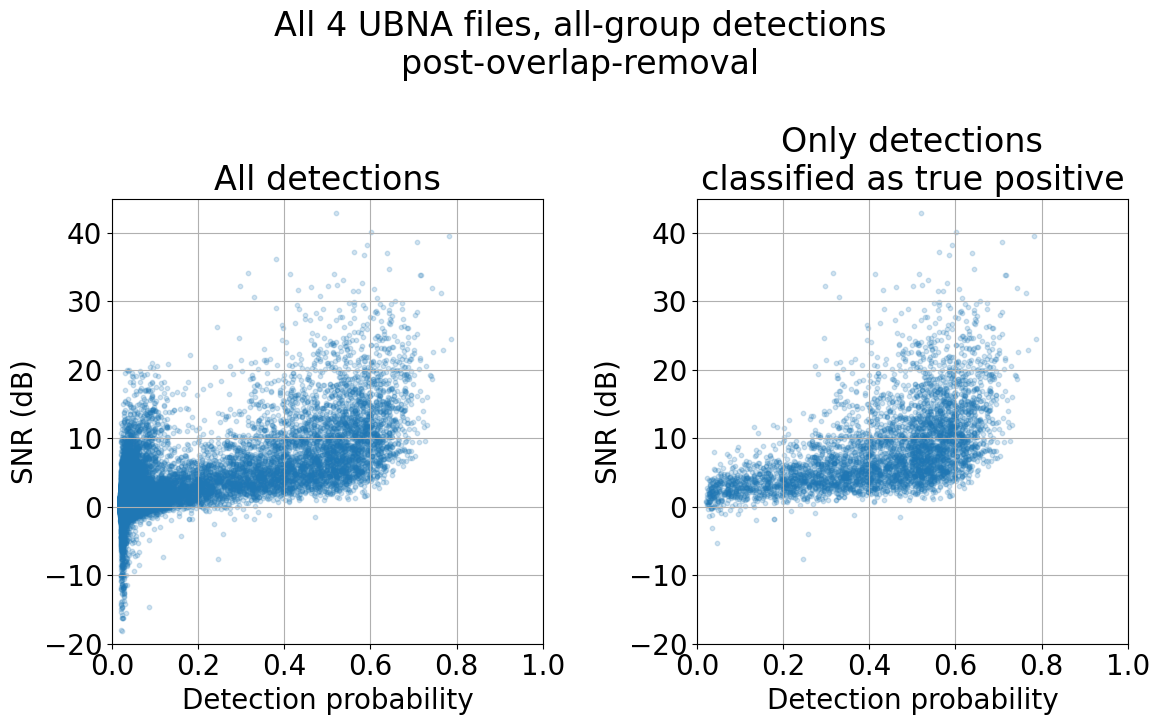

In [201]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,7.5))
plt.rcParams.update({'font.size':20})
fig.suptitle(f'All 4 UBNA files, all-group detections\npost-overlap-removal')

ax1.set_title(f'All detections')
ax1.scatter(all_files_batdetct2_df_reduced_overlaps['det_prob'].values, 
            all_files_batdetct2_df_reduced_overlaps['SNR'].values, alpha=0.2, s=10)
ax1.grid(which='both')
ax1.set_xlabel('Detection probability')
ax1.set_ylabel('SNR (dB)')
ax1.set_xlim(0, 1.0)
ax1.set_ylim(-20, 45)

ax2.set_title(f'Only detections\nclassified as true positive')
ax2.scatter(all_files_batdetct2_df_true_positives_reduced_overlaps['det_prob'].values, 
            all_files_batdetct2_df_true_positives_reduced_overlaps['SNR'].values, alpha=0.2, s=10)
ax2.grid(which='both')
ax2.set_xlabel('Detection probability')
ax2.set_ylabel('SNR (dB)')
ax2.set_xlim(0, 1.0)
ax2.set_ylim(-20, 45)

fig.tight_layout()
plt.show()

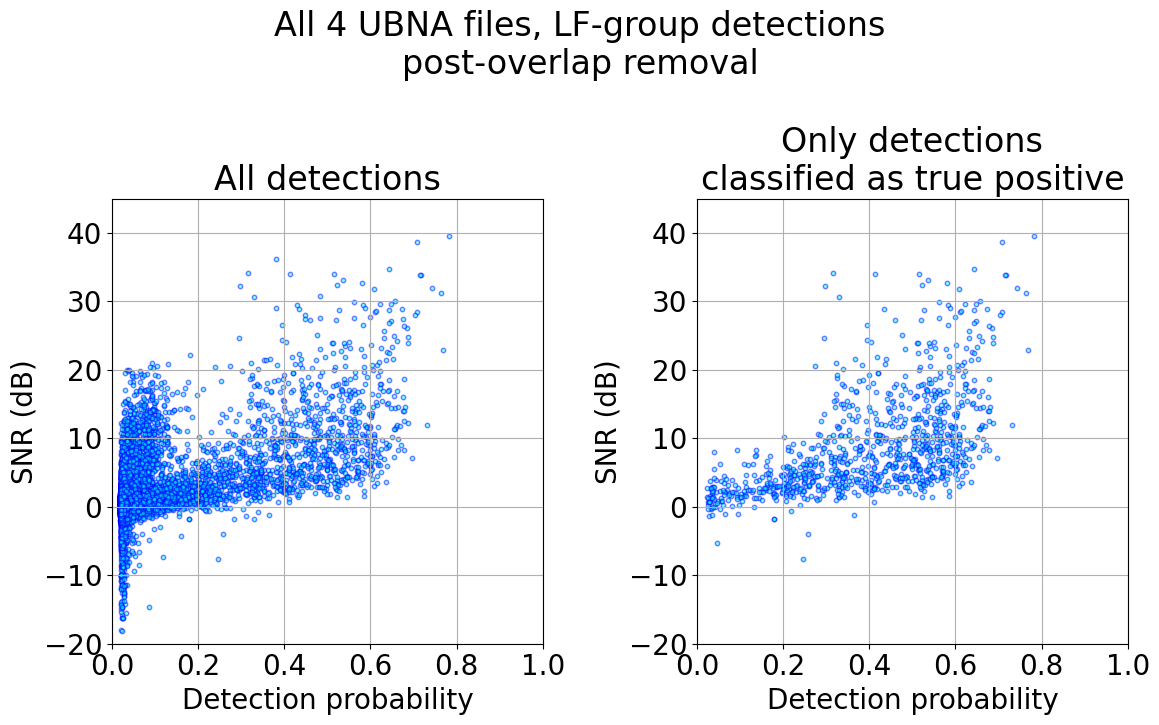

In [202]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,7.5))
plt.rcParams.update({'font.size':20})
fig.suptitle(f'All 4 UBNA files, LF-group detections\npost-overlap removal')

ax1.set_title(f'All detections')
ax1.scatter(lf_all_files_batdetct2_df_reduced_overlaps['det_prob'].values, 
            lf_all_files_batdetct2_df_reduced_overlaps['SNR'].values,
            alpha=0.5, s=10, facecolor='cyan', edgecolor='blue')
ax1.grid(which='both')
ax1.set_xlabel('Detection probability')
ax1.set_ylabel('SNR (dB)')
ax1.set_xlim(0, 1.0)
ax1.set_ylim(-20, 45)

ax2.set_title(f'Only detections\nclassified as true positive')
ax2.scatter(lf_all_files_batdetct2_df_true_positives_reduced_overlaps['det_prob'].values, 
            lf_all_files_batdetct2_df_true_positives_reduced_overlaps['SNR'].values,
            alpha=0.5, s=10, facecolor='cyan', edgecolor='blue')
ax2.grid(which='both')
ax2.set_xlabel('Detection probability')
ax2.set_ylabel('SNR (dB)')
ax2.set_xlim(0, 1.0)
ax2.set_ylim(-20, 45)

fig.tight_layout()
plt.show()

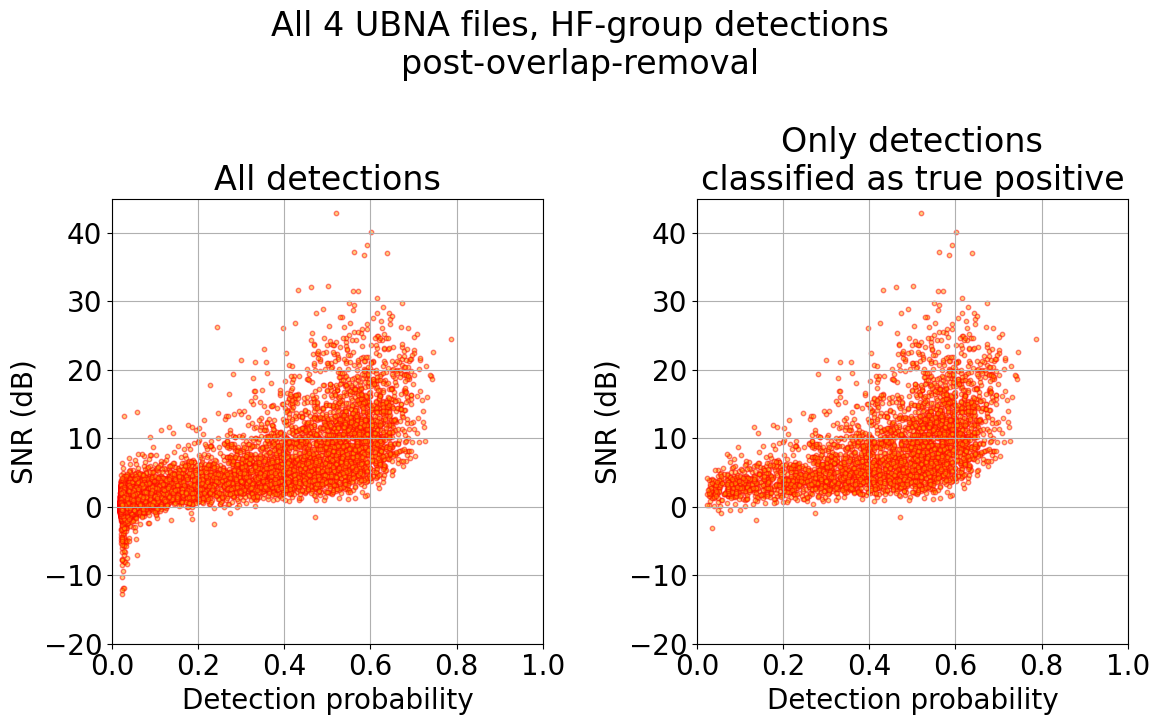

In [203]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,7.5))
plt.rcParams.update({'font.size':20})
fig.suptitle(f'All 4 UBNA files, HF-group detections\npost-overlap-removal')

ax1.set_title(f'All detections')
ax1.scatter(hf_all_files_batdetct2_df_reduced_overlaps['det_prob'].values, 
            hf_all_files_batdetct2_df_reduced_overlaps['SNR'].values,
            alpha=0.5, s=10, facecolor='orange', edgecolor='red')
ax1.grid(which='both')
ax1.set_xlabel('Detection probability')
ax1.set_ylabel('SNR (dB)')
ax1.set_xlim(0, 1.0)
ax1.set_ylim(-20, 45)

ax2.set_title(f'Only detections\nclassified as true positive')
ax2.scatter(hf_all_files_batdetct2_df_true_positives_reduced_overlaps['det_prob'].values, 
            hf_all_files_batdetct2_df_true_positives_reduced_overlaps['SNR'].values,
            alpha=0.5, s=10, facecolor='orange', edgecolor='red')
ax2.grid(which='both')
ax2.set_xlabel('Detection probability')
ax2.set_ylabel('SNR (dB)')
ax2.set_xlim(0, 1.0)
ax2.set_ylim(-20, 45)

fig.tight_layout()
plt.show()

In [204]:
batdetect2_eval = pd.DataFrame()
batdetect2_eval_LF = pd.DataFrame()
batdetect2_eval_HF = pd.DataFrame()
for file_key in file_keys:
    wav_filename = file_key
    site = file_sites[file_key]
    plot_file = Path(f'{raventxt_human_files_dir}/{wav_filename}.WAV')
    raventxt_human_filename = f'{wav_filename}_manually_verified_by_AK_with_groups'

    snr_included_ravenpro_human_txt = pd.read_csv(f'{raventxt_human_files_dir}/{raventxt_human_filename}_ravenpro_SNR_aditya_SNR_and_peakfreqtime.txt', sep=sep)
    bd2_human_df_file = snr_included_ravenpro_human_txt.copy()
    bd2_human_df_file = bd2_human_df_file.drop(columns=['Selection', 'View', 'Channel'])
    bd2_human_df_file.rename(columns={'Begin Time (s)':'start_time',
                                'End Time (s)':'end_time',
                                'Low Freq (Hz)':'low_freq',
                                'High Freq (Hz)':'high_freq',
                                'Delta Time (s)':'delta_time_s',
                                'Manually-Verified Phonic Group':'freq_group',
                                'SNR NIST Quick (dB)':'snr_nist_quick_dB'}, inplace=True)
    bd2_human_df_file.sort_values('start_time', inplace=True)

    args = dict()
    args['chunk_size'] = 2
    args['detection_threshold'] = 0.00
    ones = int(args['detection_threshold'])
    decimals = int(int(100*(args['detection_threshold'])) % 100)
    threshold_tag = f"threshold{ones}p{decimals:02}"
    save_loc_reduced_overlaps = Path(f"bd2__{threshold_tag}_chunksize{int(args['chunk_size'])}_{wav_filename}_REDUCED_OVERLAPS.csv")
    filepath_reduced_overlaps = bd2_dets_save_dir / save_loc_reduced_overlaps
    batdetect2_df_file_reduced_overlaps = pd.read_csv(filepath_reduced_overlaps, sep=',', index_col=0)
    batdetect2_df_file_reduced_overlaps.rename(columns={'KMEANS_CLASSES':'freq_group'}, inplace=True)

    batdetect2_eval_file = generate_evaluation_df(bd2_human_df_file, batdetect2_df_file_reduced_overlaps)
    batdetect2_eval_file['input_file_name'] = [f'{wav_filename}.WAV']*len(batdetect2_eval_file)
    batdetect2_eval_file['site_name'] = [SITE_NAMES[site]]*len(batdetect2_eval_file)

    bd2_human_df_file_LF = bd2_human_df_file[bd2_human_df_file['freq_group']=='LF'].copy()
    batdetect2_df_file_LF_reduced_overlaps = batdetect2_df_file_reduced_overlaps[batdetect2_df_file_reduced_overlaps['freq_group']=='LF'].copy()
    batdetect2_eval_file_LF = generate_evaluation_df(bd2_human_df_file_LF, batdetect2_df_file_LF_reduced_overlaps)
    batdetect2_eval_file_LF['input_file_name'] = [f'{wav_filename}.WAV']*len(batdetect2_eval_file_LF)
    batdetect2_eval_file_LF['site_name'] = [SITE_NAMES[site]]*len(batdetect2_eval_file_LF)

    bd2_human_df_file_HF = bd2_human_df_file[bd2_human_df_file['freq_group']=='HF'].copy()
    batdetect2_df_file_HF_reduced_overlaps = batdetect2_df_file_reduced_overlaps[batdetect2_df_file_reduced_overlaps['freq_group']=='HF'].copy()
    batdetect2_eval_file_HF = generate_evaluation_df(bd2_human_df_file_HF, batdetect2_df_file_HF_reduced_overlaps)
    batdetect2_eval_file_HF['input_file_name'] = [f'{wav_filename}.WAV']*len(batdetect2_eval_file_HF)
    batdetect2_eval_file_HF['site_name'] = [SITE_NAMES[site]]*len(batdetect2_eval_file_HF)

    batdetect2_eval = pd.concat([batdetect2_eval, batdetect2_eval_file])
    batdetect2_eval_LF = pd.concat([batdetect2_eval_LF, batdetect2_eval_file_LF])
    batdetect2_eval_HF = pd.concat([batdetect2_eval_HF, batdetect2_eval_file_HF])

0.0 0.05
0.0 0.06
0.0 0.07
0.0 0.08
0.0 0.09
0.0 0.1
0.0 0.11
0.0 0.12
0.0 0.13
0.0 0.14
0.0 0.15
0.0 0.16
0.0 0.17
0.0 0.18
0.0 0.19
0.0 0.2
0.0 0.21
0.0 0.22
0.0 0.23
0.0 0.24
0.0 0.25
0.0 0.26
0.0 0.27
0.0 0.28
0.0 0.29
0.0 0.3
0.0 0.31
0.0 0.32
0.0 0.33
0.0 0.34
0.0 0.35
0.0 0.36
0.0 0.37
0.0 0.38
0.0 0.39
0.0 0.4
0.0 0.41
0.0 0.42
0.0 0.43
0.0 0.44
0.0 0.45
0.0 0.46
0.0 0.47
0.0 0.48
0.0 0.49
0.0 0.5
0.0 0.51
0.0 0.52
0.0 0.53
0.0 0.54
0.0 0.55
0.0 0.56
0.0 0.57
0.0 0.58
0.0 0.59
0.0 0.6
2.0 0.05
2.0 0.06
2.0 0.07
2.0 0.08
2.0 0.09
2.0 0.1
2.0 0.11
2.0 0.12
2.0 0.13
2.0 0.14
2.0 0.15
2.0 0.16
2.0 0.17
2.0 0.18
2.0 0.19
2.0 0.2
2.0 0.21
2.0 0.22
2.0 0.23
2.0 0.24
2.0 0.25
2.0 0.26
2.0 0.27
2.0 0.28
2.0 0.29
2.0 0.3
2.0 0.31
2.0 0.32
2.0 0.33
2.0 0.34
2.0 0.35
2.0 0.36
2.0 0.37
2.0 0.38
2.0 0.39
2.0 0.4
2.0 0.41
2.0 0.42
2.0 0.43
2.0 0.44
2.0 0.45
2.0 0.46
2.0 0.47
2.0 0.48
2.0 0.49
2.0 0.5
2.0 0.51
2.0 0.52
2.0 0.53
2.0 0.54
2.0 0.55
2.0 0.56
2.0 0.57
2.0 0.58
2.0 0.59
2.0 0.6
4.0 

In [205]:
batdetect2_eval.to_csv(bd2_dets_save_dir / '20250123__bd2_eval_results_per_thresh_and_file.csv')
batdetect2_eval_LF.to_csv(bd2_dets_save_dir / '20250123__bd2_LFeval_results_per_thresh_and_file.csv')
batdetect2_eval_HF.to_csv(bd2_dets_save_dir / '20250123__bd2_HFeval_results_per_thresh_and_file.csv')